In [1]:
import warnings
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf
from arch import arch_model
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.svm import SVR
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from scipy.stats import norm
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")

In [2]:
# 1. Configuration of the asset matrix and systemic market trackers
tickers = {
    "Gold": "GC=F",
    "DXY": "DX-Y.NYB",
    "VIX": "^VIX",
    "US10Y": "^TNX",
    "Oil": "CL=F",
    "SPX": "^GSPC",
}

# 2. Secure structural download pooled by ticker dimensions to circumvent Multi-Index conflicts
raw_data = yf.download(
    list(tickers.values()),
    start="2019-01-01",
    end="2026-04-01",
    group_by="ticker",
)

# 3. Isolation and structural extraction of closing price vectors
data = pd.DataFrame(index=raw_data.index)
for name, ticker in tickers.items():
    if "Adj Close" in raw_data[ticker].columns:
        data[name] = raw_data[ticker]["Adj Close"]
    else:
        data[name] = raw_data[ticker]["Close"]

# 4. Continuous temporal imputation to mitigate asynchronous market holidays
data = data.ffill().dropna()

# 5. Stationarity transformation via log-returns and arithmetic first differences
returns_df = pd.DataFrame(index=data.index)
returns_df["Gold_Return"] = np.log(data["Gold"] / data["Gold"].shift(1))
returns_df["DXY_Return"] = np.log(data["DXY"] / data["DXY"].shift(1))
returns_df["VIX_Diff"] = data["VIX"].diff()
returns_df["Oil_Return"] = np.log(data["Oil"] / data["Oil"].shift(1))
returns_df["SPX_Return"] = np.log(data["SPX"] / data["SPX"].shift(1))
returns_df["US10Y_Diff"] = data["US10Y"].diff()

# Purge initialization artifacts induced by structural temporal shifting
returns_df = returns_df.dropna()

[*********************100%***********************]  6 of 6 completed


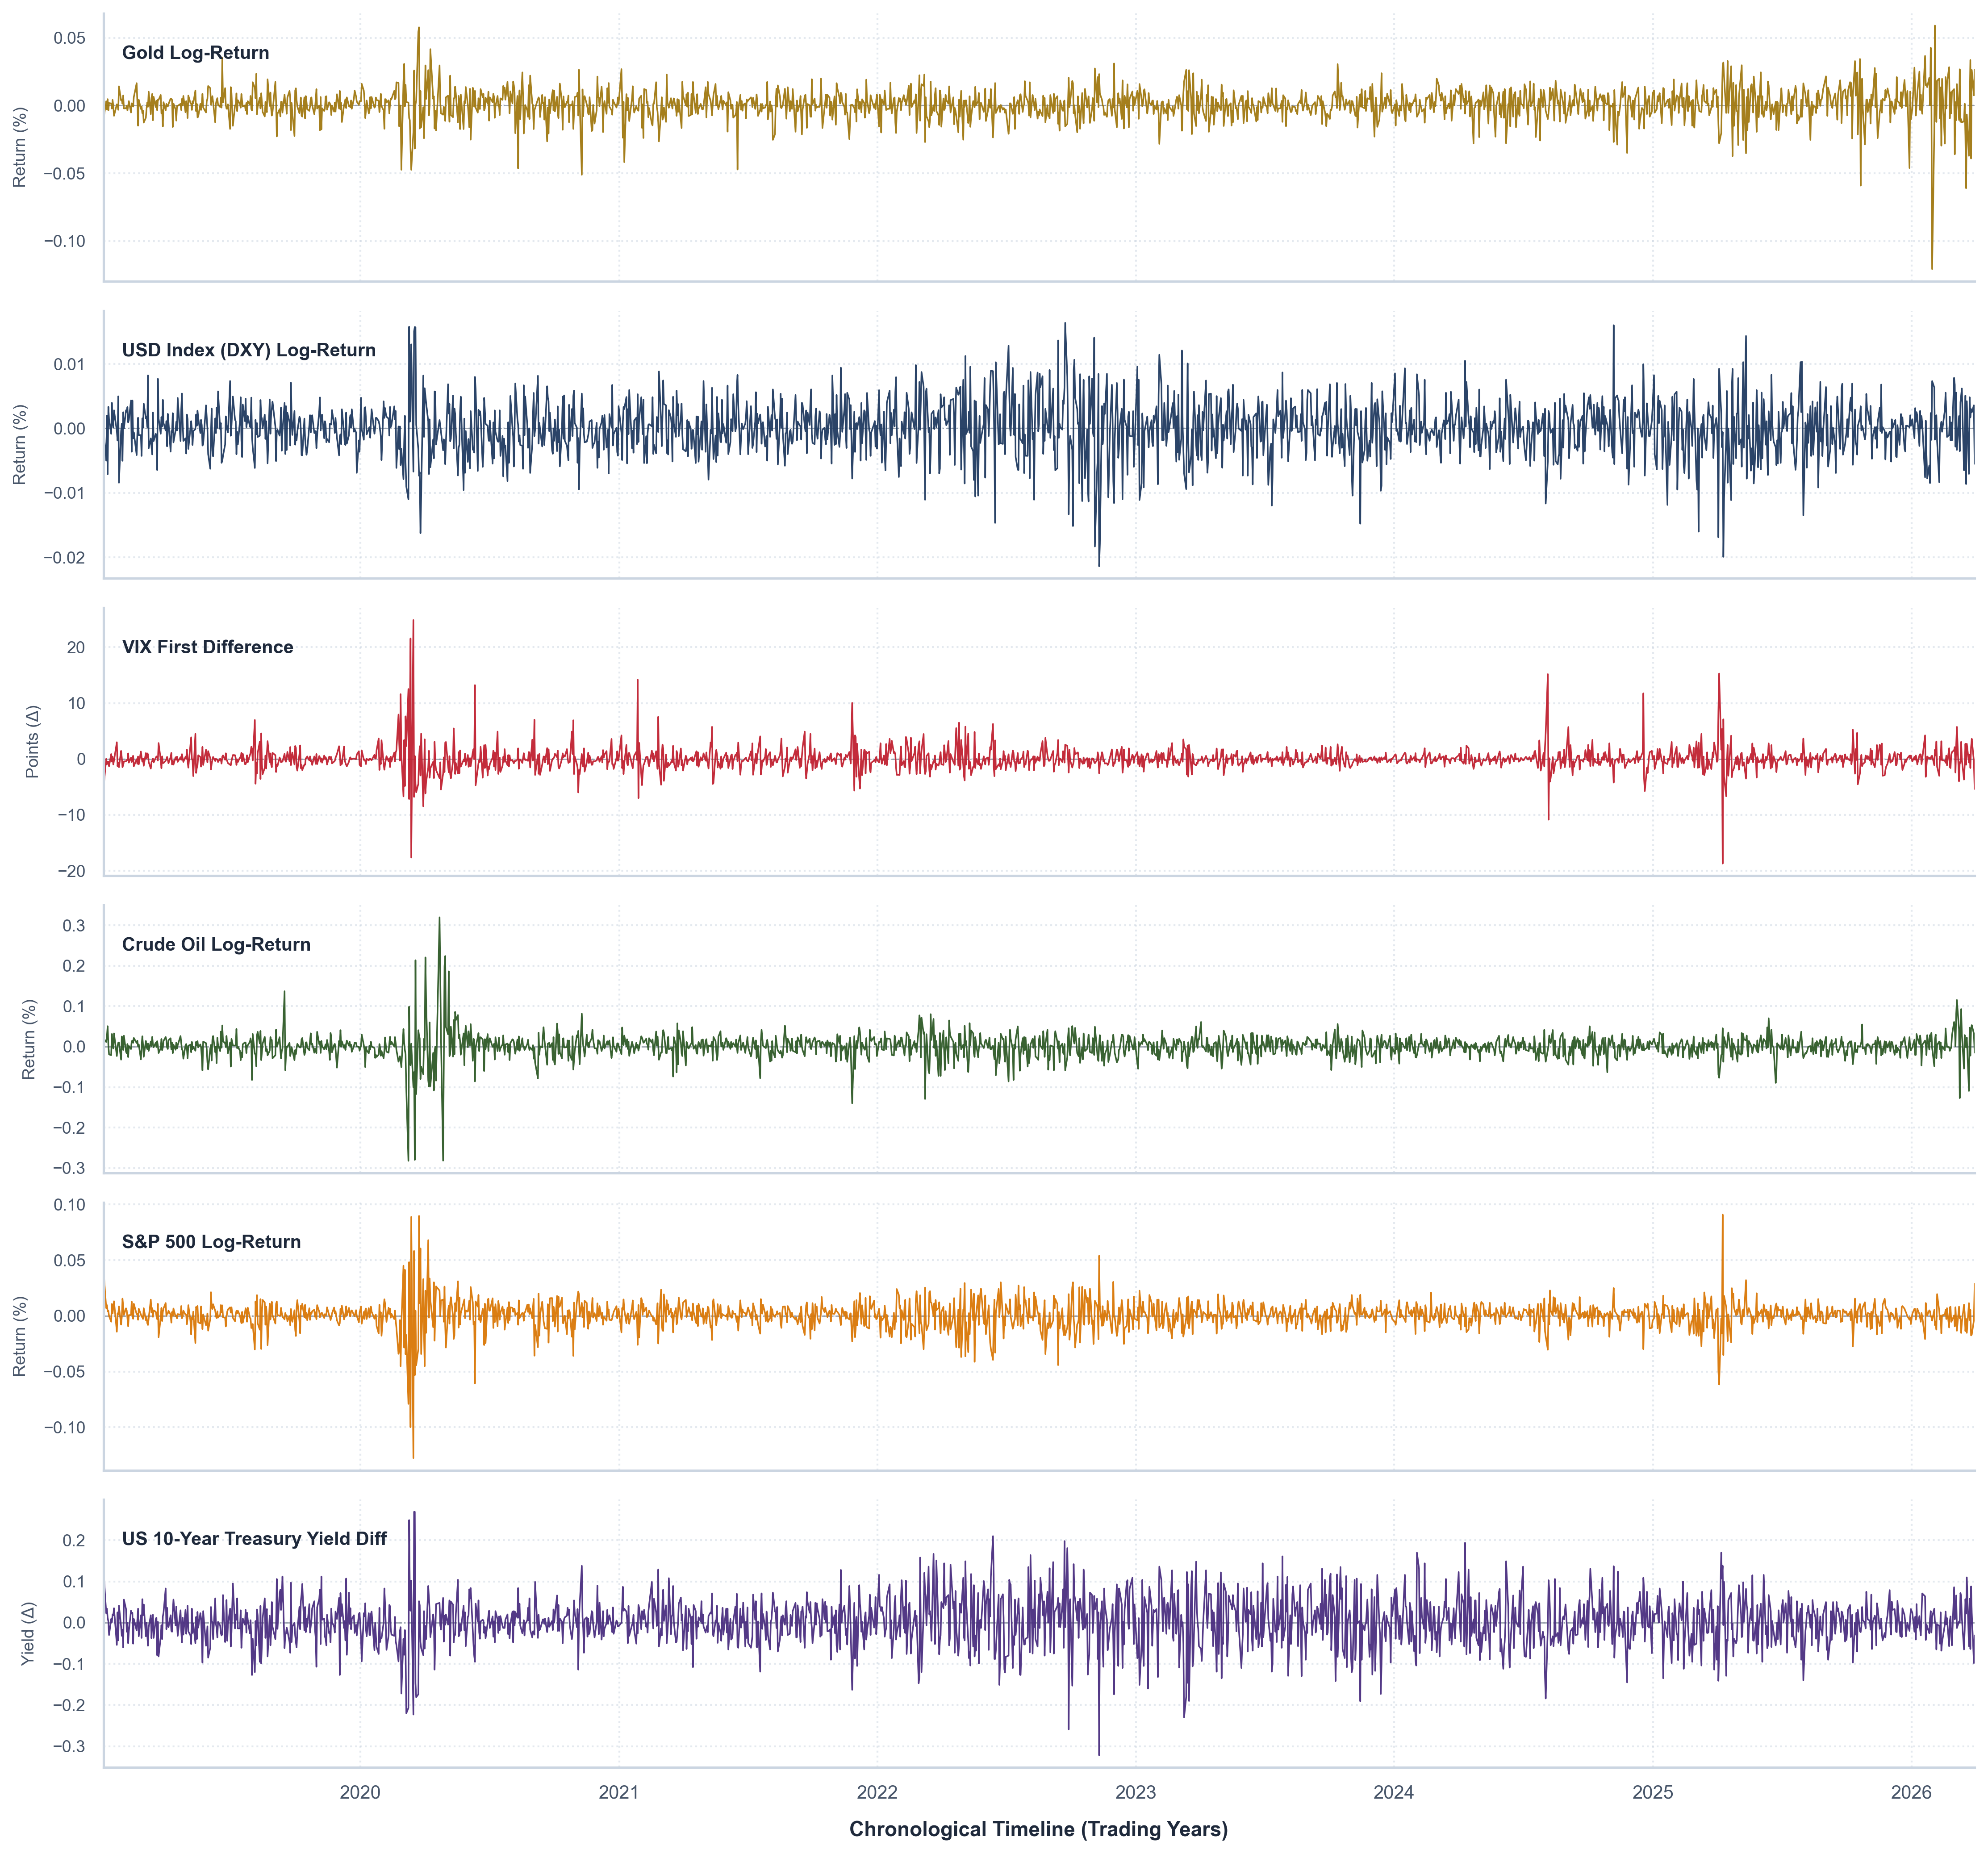

In [3]:
# 1. Feature sequence configuration and academic color palette instantiation
columns_to_plot = [
    "Gold_Return",
    "DXY_Return",
    "VIX_Diff",
    "Oil_Return",
    "SPX_Return",
    "US10Y_Diff",
]

# Standardized empirical labels for formal academic reporting
academic_labels = [
    "Gold Log-Return",
    "USD Index (DXY) Log-Return",
    "VIX First Difference",
    "Crude Oil Log-Return",
    "S&P 500 Log-Return",
    "US 10-Year Treasury Yield Diff",
]

# Differentiated Y-axis units to preserve econometric rigor
y_labels = [
    "Return (%)",
    "Return (%)",
    "Points ($\Delta$)",
    "Return (%)",
    "Return (%)",
    "Yield ($\Delta$)",
]

colors = [
    "#A07810",  # Muted Amber (Gold)
    "#1F3A60",  # Deep Navy (DXY)
    "#C02030",  # Dark Crimson (VIX)
    "#2E5A27",  # Forest Green (Crude Oil)
    "#D97706",  # Amber Orange (S&P 500)
    "#4A2E80",  # Deep Purple (US10Y)
]

# 2. Subplot matrix initialization (6 rows x 1 column) with shared X-axis
fig, axes = plt.subplots(
    nrows=6, ncols=1, figsize=(15, 14), sharex=True, dpi=300
)

# 3. Iterative graphical formatting across structural panel dimensions
for idx, col in enumerate(columns_to_plot):
    ax = axes[idx]

    # Generate time series vector profiles with minimized linewidth
    ax.plot(
        returns_df.index,
        returns_df[col],
        color=colors[idx],
        linewidth=0.85,
        alpha=0.95,
        zorder=2
    )

    # Establish zero-bound median reference vector for stationarity positioning
    ax.axhline(0, color="#475569", linestyle="-.", linewidth=0.7, alpha=0.5, zorder=1)

    # Embed precise localized panel identifier via axis transform boundaries
    ax.text(
        0.01,
        0.88,
        academic_labels[idx],
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        color="#1E293B",
        verticalalignment="top",
    )

    # Map correct mathematical unit label per asset class
    ax.set_ylabel(
        y_labels[idx], fontsize=9, labelpad=8, color="#475569"
    )

    # Configure muted background grid structural matrix
    ax.grid(True, linestyle=":", alpha=0.5, color="#CBD5E1", zorder=0)
    ax.tick_params(axis="y", labelsize=9, colors="#475569")

    # Execute spine despining to minimize peripheral visualization density
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#CBD5E1")
    ax.spines["bottom"].set_color("#CBD5E1")

    # Eradicate unnecessary border margin allocations along temporal axis
    ax.margins(x=0)

# 4. Global temporal axis customization strictly at the base subplot level
axes[-1].set_xlabel(
    "Chronological Timeline (Trading Years)",
    fontsize=11,
    fontweight="bold",
    labelpad=10,
    color="#1E293B",
)

# Critical Fix: Safe rotation directly embedded on the active shared axis axis
axes[-1].tick_params(axis="x", labelsize=10, colors="#475569", rotation=0)
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# 5. Coordinate panel constraints to maximize spatial grid dimensions and clear titles
plt.tight_layout()

# 6. Execute direct graphic rendering to the active console terminal interface
plt.show()

In [ ]:
# 1. Configuration of the exogenous variable matrix
exog_cols = ["DXY_Return", "VIX_Diff", "Oil_Return", "SPX_Return", "US10Y_Diff"]
macro_exog = returns_df[exog_cols]

diagnostic_results = []

# 2. Iterative evaluation of statistical and econometric prerequisites
for col in returns_df.columns:
    series = returns_df[col].dropna()

    # Augmented Dickey-Fuller (ADF) Unit Root Test
    adf_res = adfuller(series)
    adf_stat = adf_res[0]
    adf_p = adf_res[1]

    # Jarque-Bera (JB) Normality and Distribution Shape Diagnostics
    jb_stat, jb_p = stats.jarque_bera(series)
    skewness = stats.skew(series)
    kurtosis = stats.kurtosis(series)  # Captures Excess Kurtosis (Gaussian = 0)

    # Ljung-Box (LB) Serial Autocorrelation Test (Lag = 5)
    lb_res = acorr_ljungbox(series, lags=[5])
    lb_p = lb_res["lb_pvalue"].iloc[0]

    # Autoregressive Conditional Heteroskedasticity (ARCH-LM) Test
    # Filtration of the mean process via an ARIMA(1,0,1) baseline specification
    try:
        if col == "Gold_Return":
            model_fit = ARIMA(series, order=(1, 0, 1), exog=macro_exog).fit()
        else:
            model_fit = ARIMA(series, order=(1, 0, 1)).fit()
        arch_res = het_arch(model_fit.resid, maxlag=5)
        arch_p = arch_res[1]
    except Exception as e:
        # Contingency execution using demeaned raw series upon convergence anomalies
        arch_res = het_arch(series - series.mean(), maxlag=5)
        arch_p = arch_res[1]

    # Aggregate diagnostic metrics for the localized asset stream
    diagnostic_results.append(
        {
            "Variable": col,
            "ADF Stat": adf_stat,
            "ADF P-value": adf_p,
            "Skewness": skewness,
            "Excess Kurtosis": kurtosis,
            "JB P-value": jb_p,
            "Ljung-Box P (Lag 5)": lb_p,
            "ARCH-LM P (Lag 5)": arch_p,
        }
    )

# 3. Structural convergence into an analytical Pandas DataFrame matrix
report_df = pd.DataFrame(diagnostic_results).set_index("Variable")

# 4. Direct console printing of the raw empirical matrix for report compilation
print("\n" + "=" * 100)
print("                       PRE-ESTIMATION ECONOMETRIC DIAGNOSTIC MATRIX")
print("=" * 100)
print(report_df.round(4))  # Standardized to 4 decimal places for formal presentation
print("=" * 100)


                       PRE-ESTIMATION ECONOMETRIC DIAGNOSTIC MATRIX
             ADF Stat  ADF P-value  Skewness  Excess Kurtosis  JB P-value  \
Variable                                                                    
Gold_Return  -18.0388          0.0   -0.9725          10.6019         0.0   
DXY_Return   -19.2846          0.0   -0.2040           1.8070         0.0   
VIX_Diff     -14.7910          0.0    1.9076          29.4194         0.0   
Oil_Return    -7.3738          0.0    0.0228          24.0765         0.0   
SPX_Return   -13.0303          0.0   -0.6585          15.6392         0.0   
US10Y_Diff   -32.0466          0.0   -0.0664           1.7936         0.0   

             Ljung-Box P (Lag 5)  ARCH-LM P (Lag 5)  
Variable                                             
Gold_Return               0.4118                0.0  
DXY_Return                0.7781                0.0  
VIX_Diff                  0.0000                0.0  
Oil_Return                0.0002            

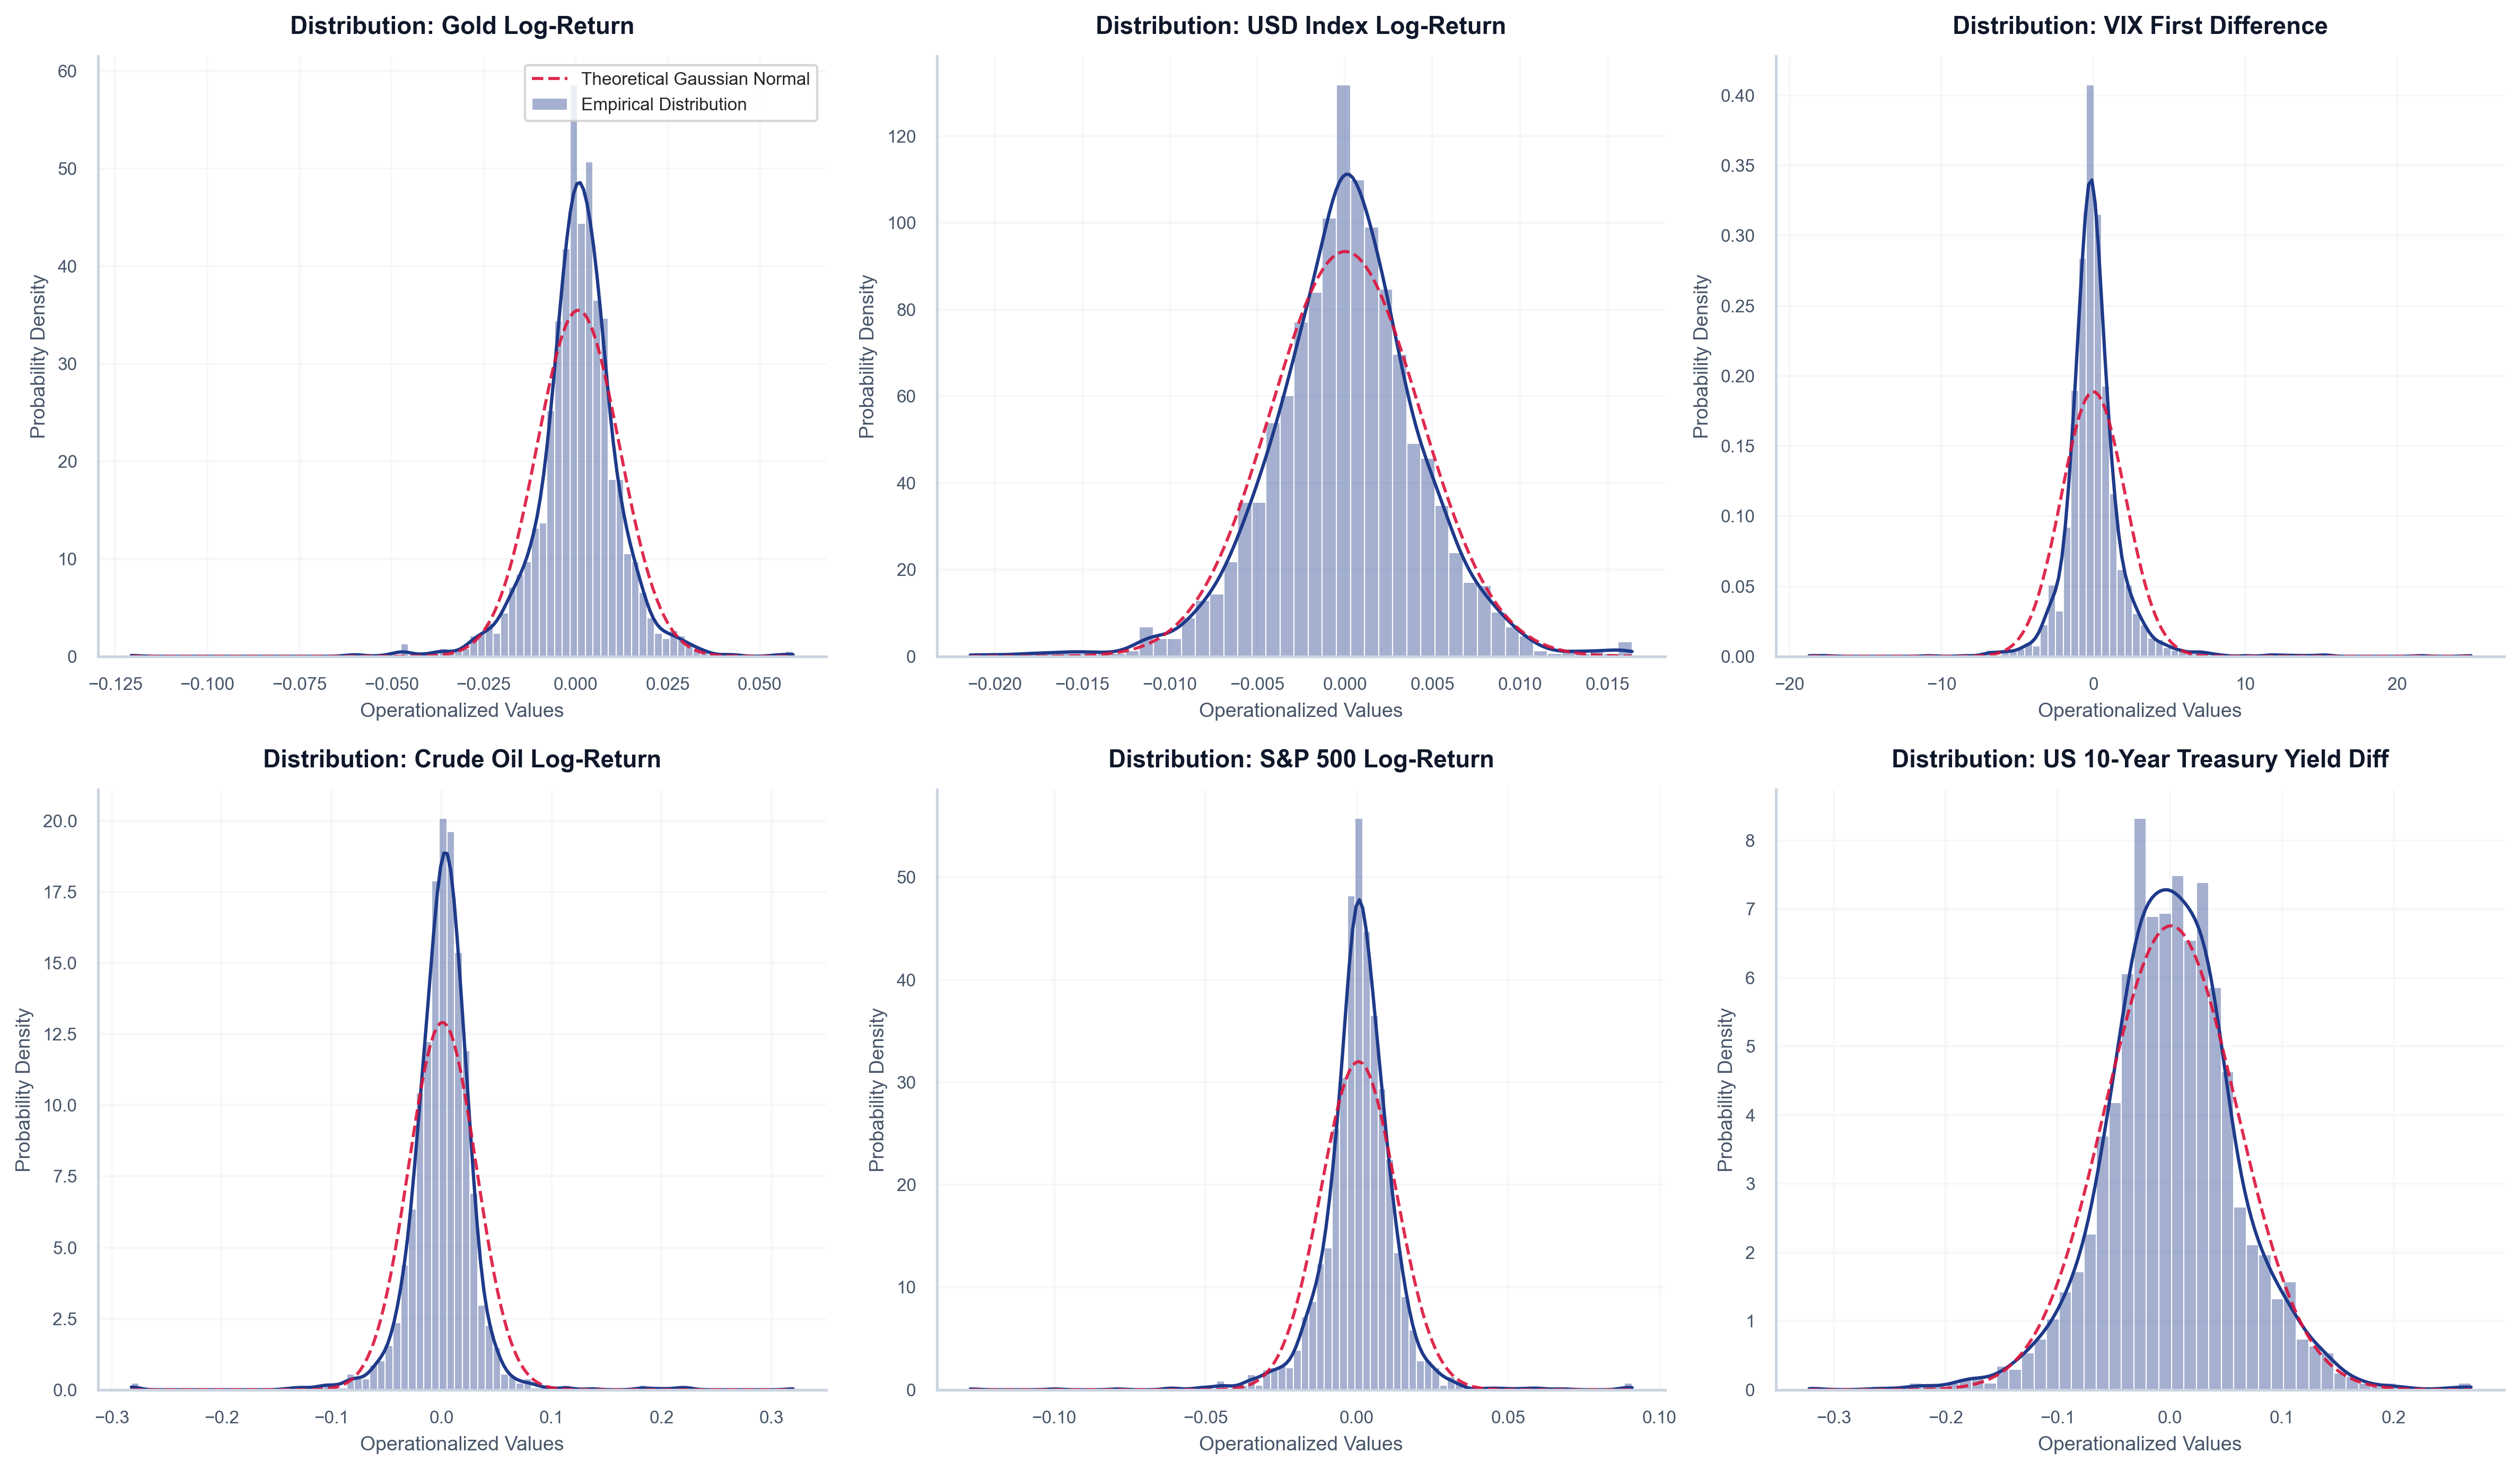

In [5]:
# 1. Configuration of the target variable sequence from the stationary matrix
cols_to_plot = returns_df.columns
num_cols = len(cols_to_plot)

# Standardized labels for formal academic reporting
academic_labels = {
    "Gold_Return": "Gold Log-Return",
    "DXY_Return": "USD Index Log-Return",
    "VIX_Diff": "VIX First Difference",
    "Oil_Return": "Crude Oil Log-Return",
    "SPX_Return": "S&P 500 Log-Return",
    "US10Y_Diff": "US 10-Year Treasury Yield Diff",
}

# 2. Subplot matrix initialization (2 rows x 3 columns) with high DPI resolution
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10), dpi=300)
axes = axes.flatten()  # Flatten the 2D spatial array to a 1D sequence for iteration

# 3. Iterative execution of density profiling and distribution diagnostics
for idx, col_name in enumerate(cols_to_plot):
    current_ax = axes[idx]

    # Step A: Generate non-parametric empirical histograms and kernel density plots
    sns.histplot(
        returns_df[col_name],
        kde=True,
        stat="density",
        color="#1E3A8A", 
        alpha=0.4,        
        edgecolor="white",
        linewidth=0.5,
        ax=current_ax,
        label="Empirical Distribution",
    )

    # Step B: Superimpose theoretical Gaussian parametric probability distributions
    # Extract structural location (mu) and scale (sigma) metrics
    b_mean = np.mean(returns_df[col_name])
    b_std = np.std(returns_df[col_name])

    # Generate an equidistant range across the variable bounds for smooth rendering
    x_range = np.linspace(
        returns_df[col_name].min(), returns_df[col_name].max(), 200
    )
    pdf_theoretical = stats.norm.pdf(x_range, b_mean, b_std)

    # Plot theoretical Gaussian normal benchmark vector as a crimson dashed line
    current_ax.plot(
        x_range,
        pdf_theoretical,
        color="#DC143C",  # Crimson Red
        linestyle="--",
        linewidth=1.4,
        alpha=0.9,
        label="Theoretical Gaussian Normal",
    )

    # Step C: Academic formatting and typography polish
    current_ax.set_title(
        f"Distribution: {academic_labels[col_name]}",
        fontsize=11,
        fontweight="bold",
        color="#0F172A",
        pad=10,
    )
    current_ax.set_xlabel("Operationalized Values", fontsize=9, color="#475569")
    current_ax.set_ylabel("Probability Density", fontsize=9, color="#475569")
    current_ax.grid(True, linestyle="-", alpha=0.3, color="#E2E8F0")
    current_ax.tick_params(axis="both", labelsize=8, colors="#475569")

    # De-spine top and right boundaries to reduce peripheral clutter
    current_ax.spines["top"].set_visible(False)
    current_ax.spines["right"].set_visible(False)
    current_ax.spines["left"].set_color("#CBD5E1")
    current_ax.spines["bottom"].set_color("#CBD5E1")

    # Isolate legend boundaries to the primary tracking layout to preserve spacing
    if idx == 0:
        current_ax.legend(fontsize=8, loc="upper right", frameon=True)

# 4. Coordinate panel constraints to optimize global canvas dimensions
plt.tight_layout(rect=[0, 0, 1, 0.94])

# 5. Execute direct graphic rendering to the active console terminal interface
plt.show()

In [6]:
train_df = returns_df.loc[:"2024-12-31"]
test_df = returns_df.loc["2025-01-01":]

y_train = train_df["Gold_Return"]
y_test = test_df["Gold_Return"]

exog_features = ["DXY_Return", "VIX_Diff", "Oil_Return", "SPX_Return", "US10Y_Diff"]
X_train = train_df[exog_features]
X_test = test_df[exog_features]

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 1507 | Test size: 314


In [7]:
arimax_base = ARIMA(y_train, order=(1, 0, 1), exog=X_train)
arimax_base_results = arimax_base.fit()

garch_base = arch_model(
    arimax_base_results.resid, vol="Garch", p=1, q=1, dist="skewt"
)
garch_base_results = garch_base.fit(disp="off")

train_sigma = garch_base_results.conditional_volatility
arimax_resid = arimax_base_results.results.resid if hasattr(arimax_base_results, 'results') else arimax_base_results.resid

print(f"Extracted features - Residuals: {len(arimax_resid)} | Sigma: {len(train_sigma)}")

Extracted features - Residuals: 1507 | Sigma: 1507


In [8]:
hybrid_features = pd.DataFrame(index=train_df.index)
hybrid_features["Arimax_Resid"] = arimax_resid
hybrid_features["Garch_Sigma"] = train_sigma

# 1. Autoregressive residue lag structures
for lag in [1, 2, 3, 5]:
    hybrid_features[f"Resid_Lag{lag}"] = hybrid_features["Arimax_Resid"].shift(lag)

# 2. Advanced residue momentum and structural indicators (Lagged to prevent leakage)
delta_res = hybrid_features["Arimax_Resid"].diff()
gain = delta_res.where(delta_res > 0, 0).rolling(window=3).mean()
loss = (-delta_res.where(delta_res < 0, 0)).rolling(window=3).mean()
hybrid_features["Resid_RSI_Lag1"] = (100 - (100 / (1 + (gain / (loss + 1e-9))))).shift(1)

exp1 = hybrid_features["Arimax_Resid"].ewm(span=2, adjust=False).mean()
exp2 = hybrid_features["Arimax_Resid"].ewm(span=5, adjust=False).mean()
hybrid_features["Resid_MACD_Lag1"] = (exp1 - exp2).shift(1)

# 3. Exogenous macroeconomic transmission feature mapping 
hybrid_features["DXY_Lag1"] = train_df["DXY_Return"].shift(1)
hybrid_features["VIX_Lag1"] = train_df["VIX_Diff"].shift(1)
hybrid_features["US10Y_Lag1"] = train_df["US10Y_Diff"].shift(1)
hybrid_features["Garch_VIX_Interaction"] = hybrid_features["Garch_Sigma"] * hybrid_features["VIX_Lag1"]

# Purge lookback initialization gaps
hybrid_features = hybrid_features.dropna()

feature_cols = [
    "Garch_Sigma", "Resid_Lag1", "Resid_Lag2", "Resid_Lag3", "Resid_Lag5",
    "Resid_RSI_Lag1", "Resid_MACD_Lag1", "DXY_Lag1", "VIX_Lag1", "US10Y_Lag1", "Garch_VIX_Interaction"
]
X_hybrid_train = hybrid_features[feature_cols]
y_hybrid_train = hybrid_features["Arimax_Resid"]

print(f"Features dimension: {X_hybrid_train.shape} | Target dimension: {y_hybrid_train.shape}")

Features dimension: (1502, 11) | Target dimension: (1502,)


In [9]:
# Regularized hyperparameters instantiated to mitigate structural overfitting
models_pool = {
    "XGBoost": XGBRegressor(
        n_estimators=50,
        learning_rate=0.02,
        max_depth=2,
        subsample=0.7,
        random_state=42,
    ),
    "RandomForest": RandomForestRegressor(
        n_estimators=50, max_depth=3, max_features=0.7, random_state=42
    ),
    "SVR": SVR(C=0.1, epsilon=0.001, kernel="rbf"),
}

# Baseline parameter estimation across the hybrid model pool
for name, model in models_pool.items():
    model.fit(X_hybrid_train, y_hybrid_train)
    print(f"Model fitted successfully: {name}")

Model fitted successfully: XGBoost
Model fitted successfully: RandomForest
Model fitted successfully: SVR


In [10]:
pure_ml_features = pd.DataFrame(index=train_df.index)
pure_ml_features["Gold_Return"] = y_train

# 1. Autoregressive price return lag structures
for lag in [1, 2, 3, 5]:
    pure_ml_features[f"Gold_Lag{lag}"] = pure_ml_features["Gold_Return"].shift(lag)

# 2. Macroeconomic transmission feature mapping 
pure_ml_features["DXY_Lag1"] = train_df["DXY_Return"].shift(1)
pure_ml_features["VIX_Lag1"] = train_df["VIX_Diff"].shift(1)

# Purge lookback initialization gaps
pure_ml_features = pure_ml_features.dropna()

pure_feature_cols = ["Gold_Lag1", "Gold_Lag2", "Gold_Lag3", "Gold_Lag5", "DXY_Lag1", "VIX_Lag1"]
X_pure_train = pure_ml_features[pure_feature_cols]
y_pure_train = pure_ml_features["Gold_Return"]

# 3. Standalone machine learning model pool instantiation and estimation
pure_models_pool = {
    "Pure_XGBoost": XGBRegressor(n_estimators=50, learning_rate=0.02, max_depth=2, random_state=42),
    "Pure_RandomForest": RandomForestRegressor(n_estimators=50, max_depth=3, random_state=42),
    "Pure_SVR": SVR(C=0.1, kernel="rbf")
}

for name, model in pure_models_pool.items():
    model.fit(X_pure_train, y_pure_train)
    print(f"Standalone model fitted successfully: {name}")

Standalone model fitted successfully: Pure_XGBoost
Standalone model fitted successfully: Pure_RandomForest
Standalone model fitted successfully: Pure_SVR


In [11]:
preds_box = {
    "ARIMA_Only": [], "Pure_XGBoost": [], "Pure_RandomForest": [], "Pure_SVR": [],
    "Hybrid_XGBoost": [], "Hybrid_RandomForest": [], "Hybrid_SVR": []
}
garch_sigma_series = []  # Retained to support Feature Engineering for Hybrid models

# Establish the baseline econometric estimation objects from the initial training set
current_arimax_results = arimax_base_results
current_garch_results = garch_base_results

# Initialize historical data structure management parameters
train_std_base = np.std(current_arimax_results.resid)
max_allowed_sigma = train_std_base * 3.5  # Upper threshold ceiling to prevent GARCH volatility explosion
max_train_resid = np.max(np.abs(current_arimax_results.resid))

# Initialize historical tracking arrays for rolling chronological expansion
history_gold = list(y_train.values)
history_resid = list(current_arimax_results.resid.values)

REFIT_PERIOD = 5 
print("Executing automated dual-dynamic chronological rolling backtest...")

for i in range(len(test_df)):
    current_date = test_df.index[i]
    
    # Construct an expanding training DataFrame to execute single-step-ahead rolling forecasts
    dynamic_train_df = pd.concat([train_df, test_df.iloc[:i]])
    y_dyn = dynamic_train_df["Gold_Return"]
    X_dyn = dynamic_train_df[["DXY_Return", "VIX_Diff", "Oil_Return", "SPX_Return", "US10Y_Diff"]]
    
    # --- PHASE 1: PERIODIC RE-ESTIMATION (MODEL WEIGHT UPDATES) ---
    if i > 0 and i % REFIT_PERIOD == 0:
        try:
            # Re-estimate the foundational macro-econometric model
            tmp_arima = ARIMA(y_dyn, order=(1, 0, 1), exog=X_dyn)
            current_arimax_results = tmp_arima.fit()
            
            tmp_garch = arch_model(current_arimax_results.resid, vol="Garch", p=1, q=1, dist="skewt")
            current_garch_results = tmp_garch.fit(disp="off", show_warning=False)
            
            # Update safety bounding parameters for the feature matrix
            train_std_base = np.std(current_arimax_results.resid)
            max_allowed_sigma = train_std_base * 3.5
            max_train_resid = np.max(np.abs(current_arimax_results.resid))
            
            # Reconstruct the feature matrix for the downstream Hybrid Machine Learning pool
            dyn_features = pd.DataFrame(index=dynamic_train_df.index)
            dyn_features["Arimax_Resid"] = current_arimax_results.resid
            dyn_features["Garch_Sigma"] = current_garch_results.conditional_volatility
            for lag in [1, 2, 3, 5]:
                dyn_features[f"Resid_Lag{lag}"] = dyn_features["Arimax_Resid"].shift(lag)
                
            d_res = dyn_features["Arimax_Resid"].diff()
            g_r = d_res.where(d_res > 0, 0).rolling(3).mean()
            l_r = (-d_res.where(d_res < 0, 0)).rolling(3).mean()
            dyn_features["Resid_RSI_Lag1"] = (100 - (100 / (1 + (g_r / (l_r + 1e-9))))).shift(1)
            dyn_features["Resid_MACD_Lag1"] = (dyn_features["Arimax_Resid"].ewm(span=2, adjust=False).mean() - dyn_features["Arimax_Resid"].ewm(span=5, adjust=False).mean()).shift(1)
            
            dyn_features["DXY_Lag1"] = dynamic_train_df["DXY_Return"].shift(1)
            dyn_features["VIX_Lag1"] = dynamic_train_df["VIX_Diff"].shift(1)
            dyn_features["US10Y_Lag1"] = dynamic_train_df["US10Y_Diff"].shift(1)
            dyn_features["Garch_VIX_Interaction"] = dyn_features["Garch_Sigma"] * dyn_features["VIX_Lag1"]
            
            # Mitigate cold-start feature gaps using mathematical backfill/forward-fill operations
            dyn_features = dyn_features.bfill().ffill()
            
            # Refit algorithmic weights for the sequential non-linear error-correction models
            for name in models_pool.keys():
                models_pool[name].fit(dyn_features[feature_cols], dyn_features["Arimax_Resid"])
        except Exception:
            pass

    # --- PHASE 2: REAL-TIME EXOGENOUS EXTRACTION ---
    if i == 0:
        dxy_lag1_val = train_df['DXY_Return'].iloc[-1]
        vix_lag1_val = train_df['VIX_Diff'].iloc[-1]
        us10y_lag1_val = train_df['US10Y_Diff'].iloc[-1]
    else:
        dxy_lag1_val = X_test['DXY_Return'].iloc[i-1]
        vix_lag1_val = X_test['VIX_Diff'].iloc[i-1]
        us10y_lag1_val = X_test['US10Y_Diff'].iloc[i-1]

    # --- PHASE 3: SCENARIO 1 — BASELINE ARIMAX FORECAST ---
    exog_t = X_test.iloc[[i]]
    y_hat_arimax = current_arimax_results.forecast(steps=1, exog=exog_t).iloc[0]
    preds_box["ARIMA_Only"].append(y_hat_arimax)

    actual_y = y_test.iloc[i]
    history_gold.append(actual_y)
    current_actual_resid = actual_y - y_hat_arimax
    history_resid.append(current_actual_resid)

    # Forecast step-ahead conditional variance to guide machine learning feature states
    try:
        garch_forecast = current_garch_results.forecast(horizon=1, align="origin")
        raw_variance = garch_forecast.variance.iloc[-1].values[0]
        
        # Enforce structural variance clipping boundaries to suppress explosive outlier noise
        sigma_next = train_std_base if np.isnan(raw_variance) or raw_variance <= 0 else np.clip(np.sqrt(raw_variance), 0.001, max_allowed_sigma)
    except Exception:
        sigma_next = train_std_base
    
    garch_sigma_series.append(sigma_next)

    # --- PHASE 4: SCENARIO 2 — STANDALONE MACHINE LEARNING INFERENCE ---
    pure_input = pd.DataFrame({
        "Gold_Lag1": [history_gold[-2]], "Gold_Lag2": [history_gold[-3]],
        "Gold_Lag3": [history_gold[-4]], "Gold_Lag5": [history_gold[-6]],
        "DXY_Lag1": [dxy_lag1_val], "VIX_Lag1": [vix_lag1_val]
    })
    pure_input = pure_input[pure_feature_cols]
    for name in ["Pure_XGBoost", "Pure_RandomForest", "Pure_SVR"]:
        preds_box[name].append(pure_models_pool[name].predict(pure_input)[0])

    # --- PHASE 5: SCENARIO 3 — HYBRID SEQUENTIAL NON-LINEAR INFERENCE ---
    res_series = pd.Series(history_resid)
    recent_resids = res_series.iloc[-4:].reset_index(drop=True) 
    delta_r = recent_resids.diff().dropna()
    gain_r = delta_r.where(delta_r > 0, 0).mean()
    loss_r = (-delta_r.where(delta_r < 0, 0)).mean()
    current_rsi = ((50.0 if gain_r < 1e-6 else 100.0) if loss_r < 1e-6 else (100 - (100 / (1 + (gain_r / loss_r)))))
    
    exp1_r = recent_resids.ewm(span=2, adjust=False).mean().iloc[-1]
    exp2_r = recent_resids.ewm(span=5, adjust=False).mean().iloc[-1]
    current_macd = exp1_r - exp2_r

    hybrid_input = pd.DataFrame({
        "Garch_Sigma": [sigma_next], 
        "Resid_Lag1": [res_series.iloc[-1]], 
        "Resid_Lag2": [res_series.iloc[-2]], 
        "Resid_Lag3": [res_series.iloc[-3]], 
        "Resid_Lag5": [res_series.iloc[-5]], 
        "Resid_RSI_Lag1": [current_rsi],
        "Resid_MACD_Lag1": [current_macd], 
        "DXY_Lag1": [dxy_lag1_val],
        "VIX_Lag1": [vix_lag1_val], 
        "US10Y_Lag1": [us10y_lag1_val],
        "Garch_VIX_Interaction": [sigma_next * vix_lag1_val]
    })
    hybrid_input = hybrid_input[feature_cols]

    for m_name in ["XGBoost", "RandomForest", "SVR"]:
        raw_err_pred = models_pool[m_name].predict(hybrid_input)[0]
        clipped_err_pred = np.clip(raw_err_pred, -1.5 * max_train_resid, 1.5 * max_train_resid)
        preds_box[f"Hybrid_{m_name}"].append(y_hat_arimax + clipped_err_pred)

print(f"Backtesting completed successfully across {len(test_df)} temporal iterations.")

Executing automated dual-dynamic chronological rolling backtest...
Backtesting completed successfully across 314 temporal iterations.


In [12]:
metrics_forecast = []

for model_name, pred_values in preds_box.items():
    y_true = np.array(y_test)
    y_pred = np.array(pred_values)

    # Statutory Mathematical Error Metrics (Mandatory)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)  # CRITICAL FIX: Replaced MAPE with R2 Score
    
    # Empirical Financial Performance (Directional Accuracy)
    true_direction = np.sign(y_true)
    pred_direction = np.sign(y_pred)
    directional_accuracy = np.mean(true_direction == pred_direction) * 100

    metrics_forecast.append(
        {
            "Model Name": model_name,
            "RMSE": round(rmse, 6),
            "MAE": round(mae, 6),
            "R2 Score": round(r2, 6),  # Updated metric key
            "Directional Acc (%)": round(directional_accuracy, 2)
        }
    )

# Compile summary DataFrame and sort by predictive precision (ascending RMSE)
summary_forecast_df = pd.DataFrame(metrics_forecast)
summary_forecast_df = summary_forecast_df.sort_values(by="RMSE").reset_index(drop=True)
winner_forecast = summary_forecast_df.iloc[0]["Model Name"]

print("=" * 80)
print("   OUT-OF-SAMPLE CONDITIONAL MEAN FORECAST ACCURACY MATRIX")
print("=" * 80)
print(summary_forecast_df.to_string(index=False))
print("=" * 80)
print(f"\n OPTIMAL ARCHITECTURE BASED ON OUT-OF-SAMPLE RMSE: {winner_forecast} ")

   OUT-OF-SAMPLE CONDITIONAL MEAN FORECAST ACCURACY MATRIX
         Model Name     RMSE      MAE  R2 Score  Directional Acc (%)
         Hybrid_SVR 0.015183 0.009940  0.141799                69.11
         ARIMA_Only 0.015594 0.010366  0.094719                65.61
     Hybrid_XGBoost 0.015611 0.010372  0.092684                64.97
Hybrid_RandomForest 0.015714 0.010461  0.080684                65.29
  Pure_RandomForest 0.016343 0.011185  0.005611                58.28
       Pure_XGBoost 0.016347 0.011158  0.005156                58.60
           Pure_SVR 0.016461 0.011083 -0.008813                58.92

 OPTIMAL ARCHITECTURE BASED ON OUT-OF-SAMPLE RMSE: Hybrid_SVR 


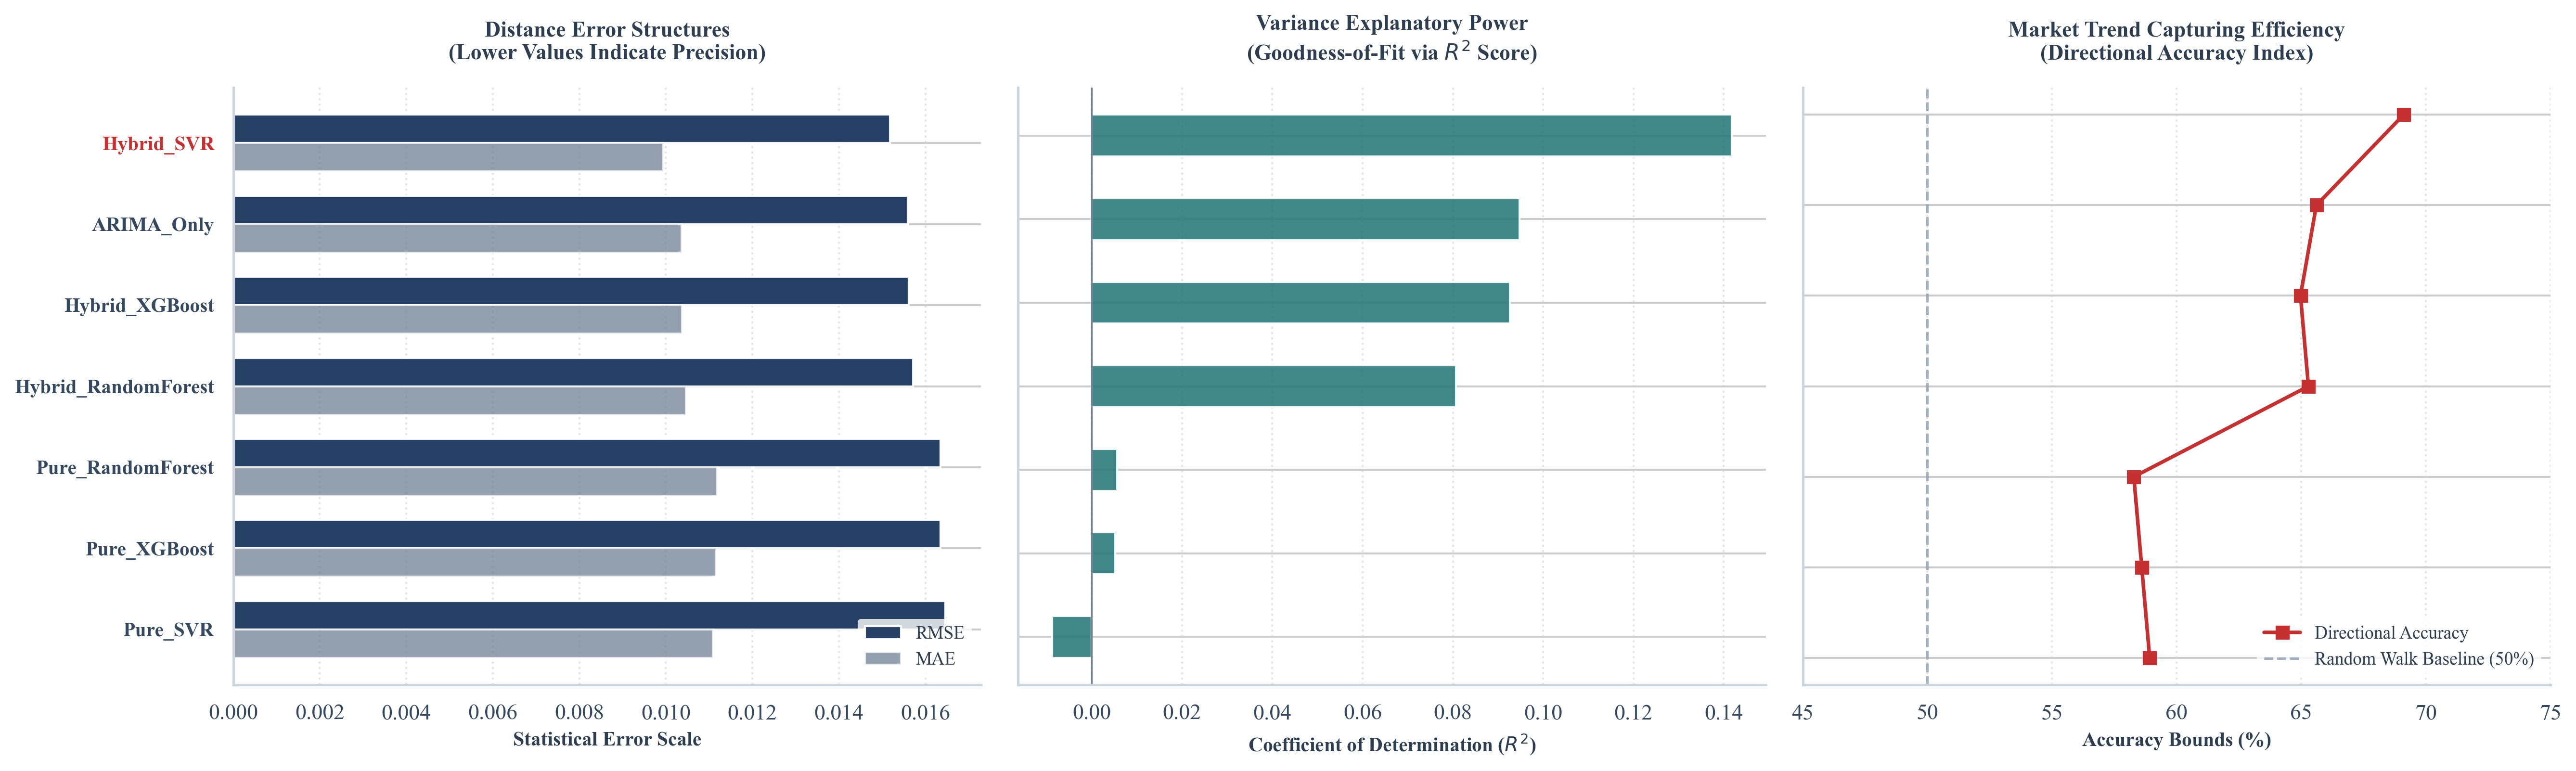

In [13]:
metrics_forecast_clean = []

for model_name, pred_values in preds_box.items():
    y_true_arr = np.array(y_test)
    y_pred_arr = np.array(pred_values)

    rmse = np.sqrt(mean_squared_error(y_true_arr, y_pred_arr))
    mae = mean_absolute_error(y_true_arr, y_pred_arr)
    r2_val = r2_score(y_true_arr, y_pred_arr) 
    
    true_direction = np.sign(y_true_arr)
    pred_direction = np.sign(y_pred_arr)
    directional_accuracy = np.mean(true_direction == pred_direction) * 100

    metrics_forecast_clean.append({
        "Model Name": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2 Score": r2_val,
        "Directional Acc (%)": directional_accuracy
    })

plot_df = pd.DataFrame(metrics_forecast_clean).sort_values(by="RMSE", ascending=True).reset_index(drop=True)
models = plot_df["Model Name"]
y_indexes = np.arange(len(models))
bar_width = 0.35

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['text.color'] = '#2c3e50'
plt.rcParams['axes.labelcolor'] = '#2c3e50'
plt.rcParams['xtick.color'] = '#34495e'
plt.rcParams['ytick.color'] = '#34495e'

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), dpi=300)

PRIMARY_BLUE = '#1a365d'    
SECONDARY_SAGE = '#718096'  
MID_TEAL = '#2c7a7b'       
HIGHLIGHT_TERRA = '#c53030' 

axes[0].barh(y_indexes - bar_width/2, plot_df["RMSE"], height=bar_width, label="RMSE", color=PRIMARY_BLUE, alpha=0.95)
axes[0].barh(y_indexes + bar_width/2, plot_df["MAE"], height=bar_width, label="MAE", color=SECONDARY_SAGE, alpha=0.75)

axes[0].set_title('Distance Error Structures\n(Lower Values Indicate Precision)', fontsize=11, fontweight='bold', pad=14)
axes[0].set_yticks(y_indexes)
axes[0].set_yticklabels(models, fontsize=10, fontweight='bold')
axes[0].set_xlabel('Statistical Error Scale', fontsize=10, fontweight='bold')
axes[0].grid(True, linestyle=':', alpha=0.5, axis='x')
axes[0].legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none', fontsize=9)

winner_idx = plot_df[plot_df["Model Name"] == winner_forecast].index[0]
axes[0].get_yticklabels()[winner_idx].set_color(HIGHLIGHT_TERRA)

axes[1].barh(y_indexes, plot_df["R2 Score"], height=0.5, color=MID_TEAL, alpha=0.9)
axes[1].set_title('Variance Explanatory Power\n(Goodness-of-Fit via $R^2$ Score)', fontsize=11, fontweight='bold', pad=14)
axes[1].set_yticks(y_indexes)
axes[1].set_yticklabels([])  # Ẩn nhãn trục hoành trùng lặp để thoáng không gian đồ thị
axes[1].set_xlabel('Coefficient of Determination ($R^2$)', fontsize=10, fontweight='bold')
axes[1].axvline(0.0, color='#718096', linestyle='-', linewidth=0.8) # Đường phân cách mốc 0
axes[1].grid(True, linestyle=':', alpha=0.5, axis='x')

axes[2].plot(plot_df["Directional Acc (%)"], y_indexes, color=HIGHLIGHT_TERRA, marker='s', 
             linewidth=1.8, markersize=6, label='Directional Accuracy')

axes[2].axvline(50.0, color='#a0aec0', linestyle='--', linewidth=1.2, label='Random Walk Baseline (50%)')

axes[2].set_title('Market Trend Capturing Efficiency\n(Directional Accuracy Index)', fontsize=11, fontweight='bold', pad=14)
axes[2].set_yticks(y_indexes)
axes[2].set_yticklabels([])  
axes[2].set_xlabel('Accuracy Bounds (%)', fontsize=10, fontweight='bold')
axes[2].set_xlim(45, 75)
axes[2].grid(True, linestyle=':', alpha=0.5, axis='x')
axes[2].legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none', fontsize=9)

for ax in axes:
    ax.invert_yaxis()  
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cbd5e0')
    ax.spines['bottom'].set_color('#cbd5e0')
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [14]:
def diebold_mariano_test(actual, pred1, pred2, h=1, power=2):
    actual = np.array(actual)
    pred1 = np.array(pred1)
    pred2 = np.array(pred2)
    
    # Calculate the forecast errors for both configurations
    e1 = actual - pred1
    e2 = actual - pred2
    
    # Define the loss differential series based on the chosen loss function power
    if power == 1:
        d = np.abs(e1) - np.abs(e2)
    else:
        d = e1**2 - e2**2
        
    mean_d = np.mean(d)
    n = len(d)
    
    # Calculate the autocovariances to adjust for potential multi-step auto-dependence
    gamma = np.zeros(h)
    gamma[0] = np.var(d)
    for lag in range(1, h):
        gamma[lag] = np.mean((d[lag:] - mean_d) * (d[:-lag] - mean_d))
        
    # Compute the heteroskedasticity and autocorrelation consistent (HAC) variance
    variance_d = gamma[0] + 2 * np.sum(gamma[1:])
    if variance_d <= 0:
        variance_d = 1e-9  # Numerical stability patch
        
    # Calculate the asymptotic Diebold-Mariano statistic
    dm_stat = mean_d / np.sqrt(variance_d / n)
    
    # Compute the two-tailed p-value under a standard normal Gaussian distribution
    p_value = 2 * (1 - norm.cdf(np.abs(dm_stat)))
    
    return dm_stat, p_value

actual_returns = y_test.values

comparisons = [
    # --- TRANCHE 1: HYBRID ENSEMBLES VS. ECONOMETRIC BASELINE ---
    ("Hybrid_SVR", "ARIMA_Only"),
    ("Hybrid_XGBoost", "ARIMA_Only"),
    ("Hybrid_RandomForest", "ARIMA_Only"),
    
    # --- TRANCHE 2: HYBRID SEQUENTIAL VS. PURE UNCONSTRAINED ML ---
    ("Hybrid_SVR", "Pure_SVR"),
    ("Hybrid_XGBoost", "Pure_XGBoost"),
    ("Hybrid_RandomForest", "Pure_RandomForest"),
    
    # --- TRANCHE 3: CROSS-CLASS ALGORITHMIC COMPETITIONS ---
    ("Hybrid_SVR", "Hybrid_XGBoost"),       
    ("Hybrid_SVR", "Hybrid_RandomForest"),  
    ("Hybrid_XGBoost", "Hybrid_RandomForest"), 
    
    # --- TRANCHE 4: BASELINE ECONOMIC EQUATION VS. PURE BLACK-BOXES ---
    ("Pure_SVR", "ARIMA_Only"),
    ("Pure_XGBoost", "ARIMA_Only")
]

stability_results = []

for model_a, model_b in comparisons:
    pred_a = np.array(preds_box[model_a])
    pred_b = np.array(preds_box[model_b])
    
    max_ae_a = np.max(np.abs(actual_returns - pred_a))
    
    dm_stat, p_val = diebold_mariano_test(actual_returns, pred_a, pred_b, h=1, power=2)
    
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    else:
        significance = ""
        
    stability_results.append({
        "Model Comparison": f"{model_a} vs. {model_b}",
        "MaxAE": round(max_ae_a, 4),
        "DM Stat": round(dm_stat, 4),
        "DM P-value": f"{p_val:.4f}{significance}"
    })

table_4_df = pd.DataFrame(stability_results)

print("\n" + "="*70)
print("       FORECAST STABILITY AND STATISTICAL SIGNIFICANCE MATRIX")
print("="*70)
print(table_4_df.to_string(index=False))
print("="*70)
print("Note: *p < 0.05, **p < 0.01, ***p < 0.001 (Squared-error loss function)")


       FORECAST STABILITY AND STATISTICAL SIGNIFICANCE MATRIX
                         Model Comparison  MaxAE  DM Stat DM P-value
                Hybrid_SVR vs. ARIMA_Only 0.1156  -6.4718  0.0000***
            Hybrid_XGBoost vs. ARIMA_Only 0.1161   0.4129     0.6797
       Hybrid_RandomForest vs. ARIMA_Only 0.1169   0.9740     0.3301
                  Hybrid_SVR vs. Pure_SVR 0.1156  -3.7579  0.0002***
          Hybrid_XGBoost vs. Pure_XGBoost 0.1161  -2.7761   0.0055**
Hybrid_RandomForest vs. Pure_RandomForest 0.1169  -2.2999    0.0215*
            Hybrid_SVR vs. Hybrid_XGBoost 0.1156  -6.0163  0.0000***
       Hybrid_SVR vs. Hybrid_RandomForest 0.1156  -3.9829  0.0001***
   Hybrid_XGBoost vs. Hybrid_RandomForest 0.1161  -0.9826     0.3258
                  Pure_SVR vs. ARIMA_Only 0.1240   2.5582    0.0105*
              Pure_XGBoost vs. ARIMA_Only 0.1211   2.7439   0.0061**
Note: *p < 0.05, **p < 0.01, ***p < 0.001 (Squared-error loss function)
